 # Анализ использования возобновляемых источников энергии

Исходный набор данных опубликован на платформе kaggle.com и доступен по ссылке:
  ## <a href="https://www.kaggle.com/datasets/mdkhurshidjahan01/energy-data">"energy-data"</a>

Он представляет собой набор ключевых энергетических показателей, опубликованных на портале
#### <a href="https://ourworldindata.org">"Our World in Data"</a>
и в отчетах
Energy Institute (EI), U.S. Energy Information Administration (EIA), The Shift Dataportal, Ember.

Объектами данных являются статистические данные по странам с 1900 до 2024 года. Признаки объектов содержат детализированную информацию по использованию первичного топлива, выработке и потреблению электроэнергии. Данные также разделены по видам топлива и включают как абсолютные, так и относительные значения. Приведены сведения по численности населения, ВВП стран и объемы выбросов СО2 в атмосферу.


Основные идеи:
1. выявить исторические тренды потребления ископаемых/возобновляемых ресурсов на электростанциях (корреляции с выработкой) по странам
2. показать тенденции выработки электроэнергии из возобновляемых источников
3. детализировать выбросы вредных веществ в атмосферу

Обучение моделей:
1. в качестве задачи примем построение регрессионной модели
2. обучим различные семейства моделей, оценим их и настроим при необходимости
3. в качестве целевой примем переменную выбросов СО2 (greenhouse_gas_emissions, миллион тонн)

# 1. Импорт библиотек и данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mdkhurshidjahan01/energy-data")


100%|██████████| 2.51M/2.51M [00:00<00:00, 2.92MB/s]

Extracting files...


In [3]:
file_path_data = os.path.join(path, 'energy-data-master/owid-energy-data.csv')
file_path_codebook = os.path.join(path, 'energy-data-master/owid-energy-codebook.csv')

In [4]:
df = pd.read_csv(file_path_data)
df_book = pd.read_csv(file_path_codebook)

Датафрейм df содержит непосредственно исходные данные, df_book - описание данных по колонкам. Взглянем на них.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [6]:
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [7]:
print(f'Общее количесвто стран: {len(df['country'].unique())}')
print(f'Временной диапазон: {df['year'].min()} - {df['year'].max()} года')


Общее количесвто стран: 314
Временной диапазон: 1900 - 2024 года


Выведем df_book полностью. В дальнейшем он еще не раз пригодится.

In [8]:
df_book[:51]

,column,title,description,unit,source
0,country,Country,Geographic location.,NaN,Our World in Data - Regions (2024)
1,year,Year,Year of observation.,NaN,Our World in Data - Regions (2024)
2,iso_code,ISO code,ISO 3166-1 alpha-3 three-letter country codes.,NaN,International Organization for Standardization...
3,population,Population,"Population by country, available from 10,000 B...",people,Population based on various sources (2024) [ht...
4,gdp,Gross domestic product (GDP),Total economic output of a country or region p...,international-$ in 2011 prices ($),Bolt and van Zanden – Maddison Project Databas...
5,biofuel_cons_change_pct,Annual percentage change in biofuel consumption,Includes biogasoline (such as ethanol) and bio...,%,Energy Institute - Statistical Review of World...
6,biofuel_cons_change_twh,Annual change in biofuel consumption,Includes biogasoline (such as ethanol) and bio...,terawatt-hours (TWh),Energy Institute - Statistical Review of World...
7,biofuel_cons_per_capita,Biofuel consumption per capita,Measured in kilowatt-hours per person.,kilowatt-hours (kWh),Energy Institute - Statistical Review of World...
8,biofuel_consumption,Primary energy consumption from biofuels,Measured in terawatt-hours.,terawatt-hours (TWh),Energy Institute - Statistical Review of World...
9,biofuel_elec_per_capita,Electricity generation from bioenergy per person,Measured in kilowatt-hours per person.,kilowatt-hours (kWh),Ember - Yearly Electricity Data Europe (2025) ...


In [9]:
df_book[51:101]

,column,title,description,unit,source
51,gas_production,Gas production,Measured in terawatt-hours.,terawatt-hours (TWh),Energy Institute - Statistical Review of World...
52,gas_share_elec,Share of electricity generated by gas,Measured as a percentage of total electricity ...,%,Ember - Yearly Electricity Data Europe (2025) ...
53,gas_share_energy,Share of primary energy consumption that comes...,Measured as a percentage of the total primary ...,%,Energy Institute - Statistical Review of World...
54,greenhouse_gas_emissions,Emissions from electricity generation,Measured in megatonnes of CO₂ equivalents.,million tonnes CO₂ equivalents (Mt),Ember - Yearly Electricity Data Europe (2025) ...
55,hydro_cons_change_pct,Annual percentage change in hydropower consump...,Figures are based on gross primary hydroelectr...,%,Energy Institute - Statistical Review of World...
56,hydro_cons_change_twh,Annual change in hydropower consumption,Input-equivalent energy is based on gross gene...,terawatt-hours (TWh),Energy Institute - Statistical Review of World...
57,hydro_consumption,Primary energy consumption from hydropower,"Measured in terawatt-hours, using the substitu...",terawatt-hours (TWh),Energy Institute - Statistical Review of World...
58,hydro_elec_per_capita,Electricity generation from hydropower per person,Measured in kilowatt-hours per person.,kilowatt-hours (kWh),Ember - Yearly Electricity Data Europe (2025) ...
59,hydro_electricity,Electricity generation from hydropower,Measured in terawatt-hours.,terawatt-hours (TWh),Ember - Yearly Electricity Data Europe (2025) ...
60,hydro_energy_per_capita,Hydropower consumption per capita,Measured in kilowatt-hours per person.,kilowatt-hours (kWh),Energy Institute - Statistical Review of World...


In [10]:
df_book[101:]

,column,title,description,unit,source
101,other_renewables_share_elec,Share of electricity generated by other renewa...,Measured as a percentage of total electricity ...,%,Ember - Yearly Electricity Data Europe (2025) ...
102,other_renewables_share_elec_exc_biofuel,Share of electricity generated by other renewa...,Measured as a percentage of total electricity ...,%,Ember - Yearly Electricity Data Europe (2025) ...
103,other_renewables_share_energy,Share of primary energy consumption that comes...,Measured as a percentage of the total primary ...,%,Energy Institute - Statistical Review of World...
104,per_capita_electricity,Total electricity generation per person,Measured in kilowatt-hours per person.,kilowatt-hours (kWh),Ember - Yearly Electricity Data Europe (2025) ...
105,primary_energy_consumption,Primary energy consumption,Measured in terawatt-hours.,terawatt-hours (TWh),U.S. Energy Information Administration - Inter...
106,renewables_cons_change_pct,Annual percentage change in renewables consump...,NaN,%,Energy Institute - Statistical Review of World...
107,renewables_cons_change_twh,Annual change in renewables consumption,NaN,terawatt-hours (TWh),Energy Institute - Statistical Review of World...
108,renewables_consumption,Primary energy consumption from renewables,"Measured in terawatt-hours, using the substitu...",terawatt-hours (TWh),Energy Institute - Statistical Review of World...
109,renewables_elec_per_capita,Electricity generation from renewables per person,Measured in kilowatt-hours per person.,kilowatt-hours (kWh),Ember - Yearly Electricity Data Europe (2025) ...
110,renewables_electricity,Electricity generation from renewables,Measured in terawatt-hours.,terawatt-hours (TWh),Ember - Yearly Electricity Data Europe (2025) ...


# 2. Анализ данных

В данном контексте данные по типам источника энергии структурированы следующим образом (приведены в ТВт·ч*):
- **fossil_fuel_consumption** - потребление ископаемого топлива, в том числе:
> - coal_consumption - угля
> - oil_consumption - нефти
> - gas_consumption - газа


- **low_carbon_consumption** - потребление низкоуглеродного топлива, в том числе:
> - nuclear_consumption - ядерного топлива
> - **renewables_consumption** - возобновляемой энергии, в том числе:
>> - hydro_consumption - гидроэнергии
>> - solar_consumption - энергии солнца
>> - wind_consumption - энергии ветра
>> - other_renewable_consumption (biofuel и прочие) - другие источники

*1 ТВт·ч (тераватт-час) = 1 000 000 000 кВт·ч (киловатт-час))


## 2.1. Оценка полноты данных

In [11]:
df.count()

,0
country,23195
year,23195
iso_code,17099
population,18724
gdp,11780
...,...
wind_elec_per_capita,8301
wind_electricity,9871
wind_energy_per_capita,5145
wind_share_elec,7868


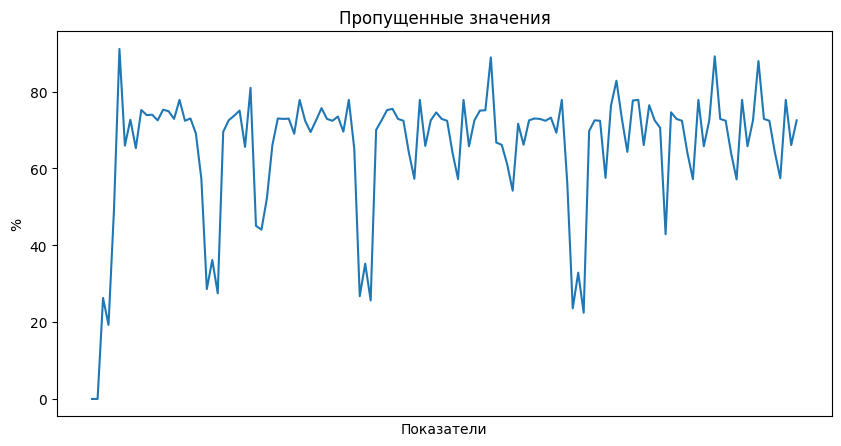

In [12]:
nans=df.isna().sum()/231.95

plt.figure(figsize=(10,5))
sns.lineplot(nans)
plt.xlabel('Показатели')
plt.ylabel('%')
plt.xticks([])
plt.title('Пропущенные значения')
plt.show()

Видим, что пропусков очень много. Это может быть связано с тем, что данные приведены для большого промежутка времени и значительного количества стран, для которых более ранняя информация могла быть недоступна. Проверим это. Для начала переформатируем исходный датафрейм с выделем индекса и подсчетом общего значения каждого признака (абсолютных значений) для всех стран. Перед этим удалим расчетные относительные показатели (%, */чел, г/кВтч), суммирование которых не будет иметь смысла.

In [13]:
import re
cols_to_drop_pct=list(df_book.loc[(df_book['unit']=='%') | (df_book['unit']=='grams of CO₂ equivalents per kilowatt-hour (gCO₂)'), 'column'].values)
cols_to_drop_per = list(filter(lambda x: re.search(r'per_', x), list(df_book['column'])))
cols_to_drop=cols_to_drop_pct + cols_to_drop_per + ['country', 'iso_code', 'population', 'gdp', 'net_elec_imports']

len(cols_to_drop)


81

In [14]:
df_world=df.loc[df['country']=='World']
df_year=df_world.set_index(['year'])
df_year.drop(cols_to_drop, axis=1, inplace=True)

df_year

,biofuel_cons_change_twh,biofuel_consumption,biofuel_electricity,coal_cons_change_twh,coal_consumption,coal_electricity,coal_prod_change_twh,coal_production,electricity_demand,electricity_generation,...,primary_energy_consumption,renewables_cons_change_twh,renewables_consumption,renewables_electricity,solar_cons_change_twh,solar_consumption,solar_electricity,wind_cons_change_twh,wind_consumption,wind_electricity
year,,,,,,,,,,,,,,,,,,,,,
1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5349.888,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1901,NaN,NaN,NaN,NaN,NaN,NaN,96.707,5446.595,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1902,NaN,NaN,NaN,NaN,NaN,NaN,131.829,5578.424,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1903,NaN,NaN,NaN,NaN,NaN,NaN,508.836,6087.260,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1904,NaN,NaN,NaN,NaN,NaN,NaN,30.981,6118.242,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,-59.084,1068.230,615.21,-1311.289,42316.324,9437.11,-2316.449,43486.125,26742.910,26742.910,...,157993.891,1104.453,20040.709,7495.79,367.915,2116.744,855.23,419.721,3940.165,1591.37
2021,59.890,1128.119,669.27,2325.840,44642.164,10154.13,1873.359,45359.484,28271.260,28271.260,...,166043.500,1156.360,21197.068,7953.64,476.337,2593.081,1053.49,642.617,4582.781,1856.65
2022,65.012,1193.131,684.83,284.762,44926.926,10263.17,3189.062,48548.547,28926.930,28926.930,...,169061.531,1460.484,22657.553,8530.51,656.664,3249.746,1329.69,601.820,5184.602,2106.93


Построим heatmap распределения признаков по годам. Однако видим, что данные содержат отрицательные значения, поэтому при масштабировании стандартным MinMaxscaler-ом нулевые значения (суть отсутствующие данные) сдвинутся и станут отличны от нуля. Чтобы этого избежать определим функцию масштабирования данных в диапазоне [-1,1] с сохранением позиции нуля:

In [15]:
def scaler_symmetric(data):
    max_abs = np.abs(data).max()
    return data / max_abs

И применим к нашему набору:

In [16]:
df_year_scaled = df_year.copy()
df_year_scaled = df_year_scaled.apply(scaler_symmetric)
df_year_scaled.head()

,biofuel_cons_change_twh,biofuel_consumption,biofuel_electricity,coal_cons_change_twh,coal_consumption,coal_electricity,coal_prod_change_twh,coal_production,electricity_demand,electricity_generation,...,primary_energy_consumption,renewables_cons_change_twh,renewables_consumption,renewables_electricity,solar_cons_change_twh,solar_consumption,solar_electricity,wind_cons_change_twh,wind_consumption,wind_electricity
year,,,,,,,,,,,,,,,,,,,,,
1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105691,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1901,NaN,NaN,NaN,NaN,NaN,NaN,0.030325,0.107601,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1902,NaN,NaN,NaN,NaN,NaN,NaN,0.041338,0.110206,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1903,NaN,NaN,NaN,NaN,NaN,NaN,0.159557,0.120258,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1904,NaN,NaN,NaN,NaN,NaN,NaN,0.009715,0.120870,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


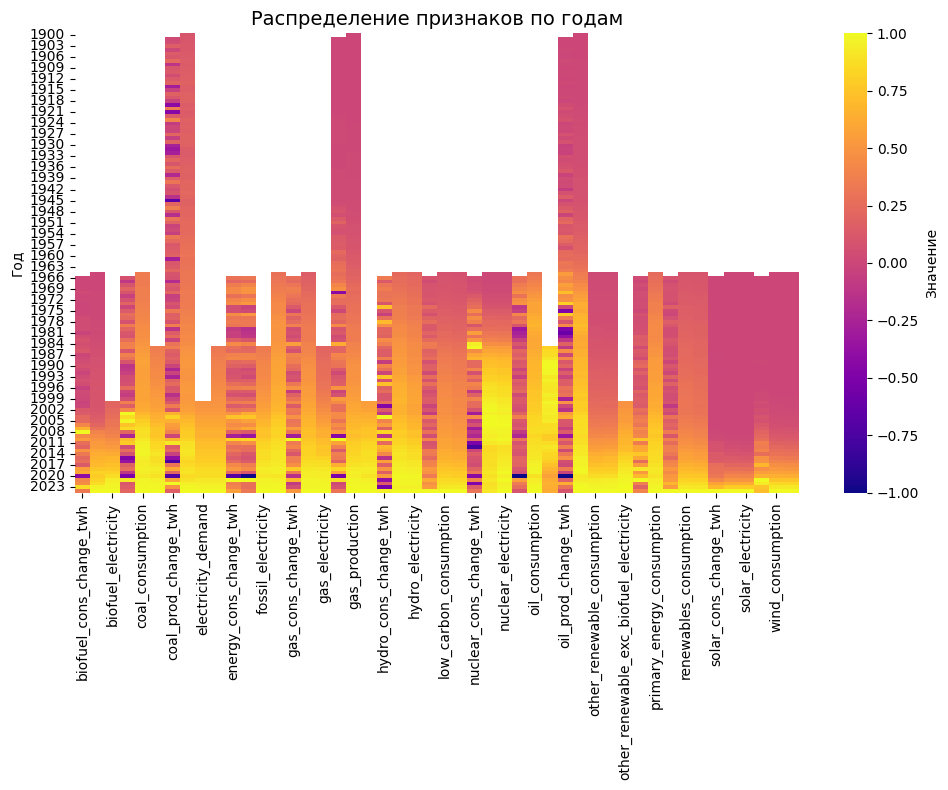

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_year_scaled, cmap='plasma', cbar_kws={'label': 'Значение'})
plt.ylabel('Год')
plt.title('Распределение признаков по годам', fontsize=14)
plt.tight_layout()
plt.show()

Видим, что исторические данные имеются только для показателей добычи угля (coal_production), нефти (oil_production) и газа (gas_production), а основной объем данных доступен только с 1960-х годов. Отредактируем датасет.

In [18]:
df_year_short=df_year.loc[1970:]

## 2.2. Динамика и структура мирового потребления ресурсов

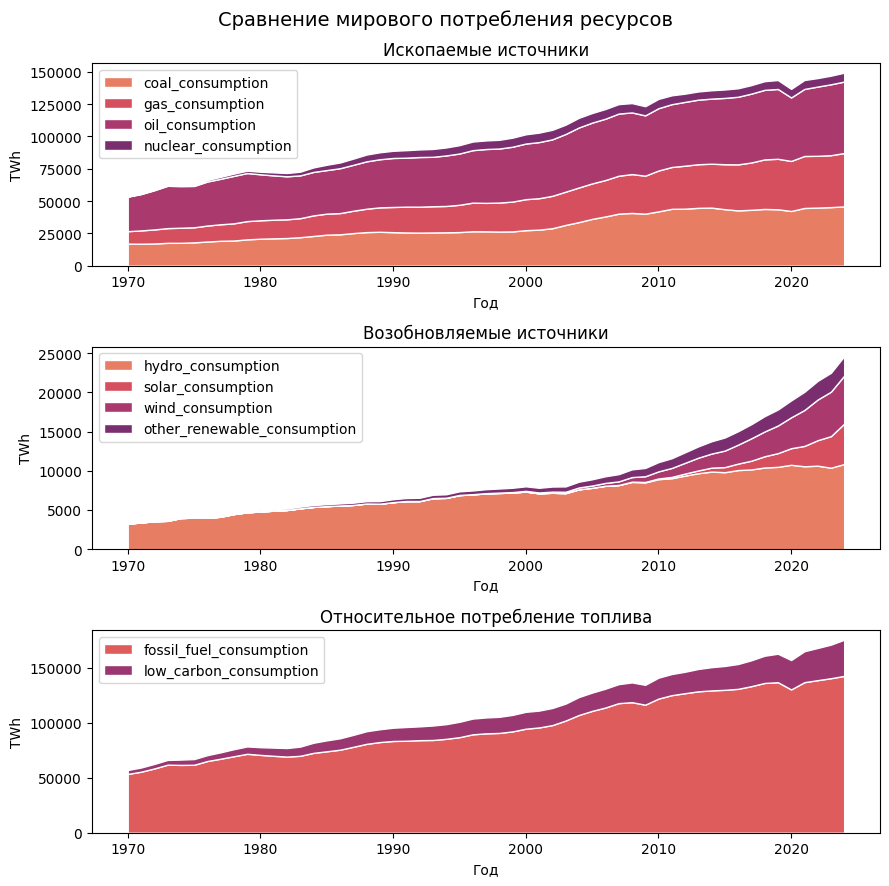

In [19]:
# приведем структуру потребления отдельных видов топлива

fig, axes = plt.subplots(3, 1, figsize=(9, 9))
axes = axes.ravel()

cols_to_stack = [
    ['coal_consumption','gas_consumption','oil_consumption','nuclear_consumption'],
    ['hydro_consumption', 'solar_consumption','wind_consumption','other_renewable_consumption'],
    ['fossil_fuel_consumption','low_carbon_consumption']
    ]
title = ['Ископаемые источники','Возобновляемые источники', 'Относительное потребление топлива']

for idx,ax in enumerate(axes):
    ax.stackplot(df_year_short.index,
                 [df_year_short[col] for col in cols_to_stack[idx]],
                 labels=cols_to_stack[idx],
                 edgecolor='white',
                 colors=sns.color_palette("flare", len(cols_to_stack[idx]))
                 )
    ax.set_title(f'{title[idx]}', fontsize=12)
    ax.set_xlabel('Год')
    ax.set_ylabel('TWh')
    ax.legend(loc='best', fontsize=10)
    #ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle('Сравнение мирового потребления ресурсов', fontsize=14)
plt.tight_layout()
plt.show()


Видим, что общая тенденция увеличения потребления топлива (любых его видов) сохраняется от года к году. Доля ископаемых ресурсов в общей добыче значительно выше доли возобновляемых, однако наблюдается ежегодное увеличение последней. При этом виден резкий рост потребления солнечной, ветряной и прочей возобновляемой энергии с середины 2000-х годов при стабильном плавном росте потребления гидроэнергии.

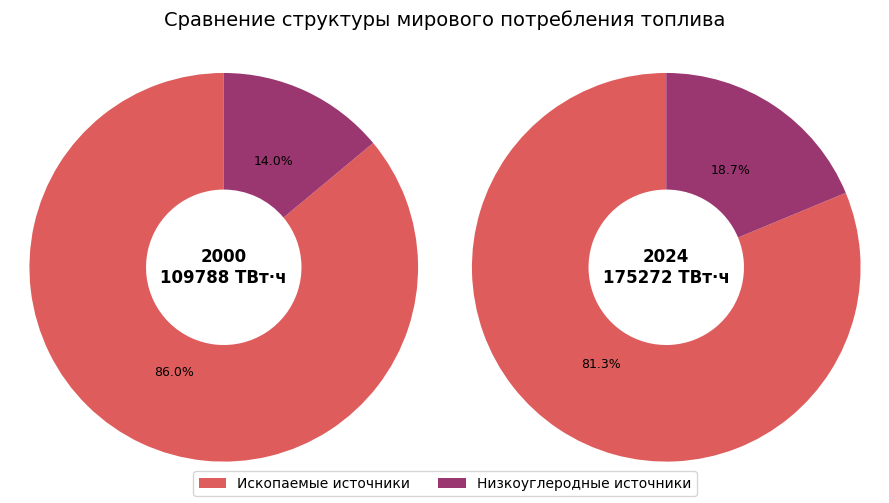

In [20]:
# вычислим доли потребления топлива

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
years = [2000, 2024]
colors = sns.color_palette('flare', n_colors=2)

for ax, year in zip(axes, years):
    data = df_year_short.loc[year, ['fossil_fuel_consumption', 'low_carbon_consumption']]
    total = data.sum()

    # Создаем кольцевую диаграмму
    wedges, texts, autotexts = ax.pie(
        data,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.6),
        textprops={'fontsize': 9}
    )

    # Центральный круг
    centre_circle = plt.Circle((0,0), 0.20, fc='white')
    ax.add_artist(centre_circle)

    # Текст в центре
    ax.text(0, 0, f'{year}\n{total:.0f} ТВт·ч',
            ha='center', va='center', fontsize=12, fontweight='bold')

    ax.axis('equal')

# Общая легенда
fig.legend(wedges, ['Ископаемые источники', 'Низкоуглеродные источники'],
           loc='lower center',
           ncol=2)

plt.suptitle('Сравнение структуры мирового потребления топлива', fontsize=14)
plt.tight_layout()
plt.show()

Расчет показывает увеличение доли низкоуглеродных ресурсов в общей структуре потребления с 14% в 2000 году до 18,7% в 2024 году. Рост незначительный, однако это тоже рост.

## 2.3. Динамика мировой генерации электроэнергии

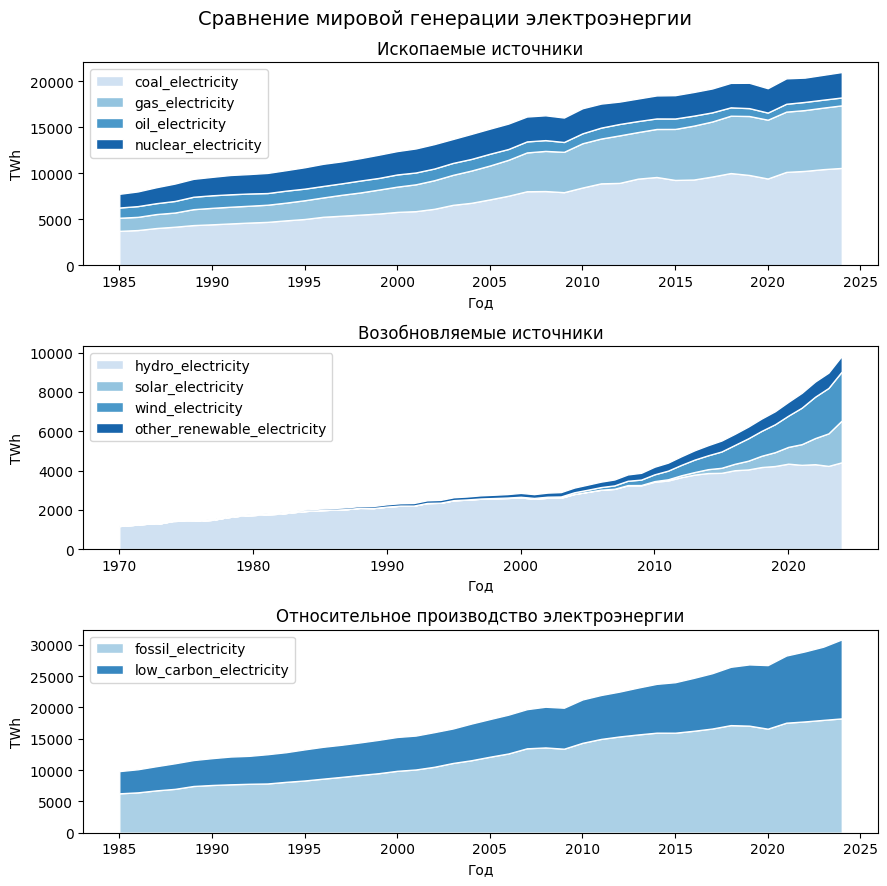

In [21]:
# приведем структуру выработки электроэнергии

fig, axes = plt.subplots(3, 1, figsize=(9, 9))
axes = axes.ravel()

cols_to_stack = [
    ['coal_electricity','gas_electricity','oil_electricity','nuclear_electricity'],
    ['hydro_electricity', 'solar_electricity','wind_electricity','other_renewable_electricity'],
    ['fossil_electricity','low_carbon_electricity']
    ]
title = ['Ископаемые источники','Возобновляемые источники', 'Относительное производство электроэнергии']

for idx,ax in enumerate(axes):
    ax.stackplot(df_year_short.index,
                 [df_year_short[col] for col in cols_to_stack[idx]],
                 labels=cols_to_stack[idx],
                 edgecolor='white',
                 colors=sns.color_palette("Blues", len(cols_to_stack[idx]))
                 )
    ax.set_title(f'{title[idx]}', fontsize=12)
    ax.set_xlabel('Год')
    ax.set_ylabel('TWh')
    ax.legend(loc='best', fontsize=10)
    #ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle('Сравнение мировой генерации электроэнергии', fontsize=14)
plt.tight_layout()
plt.show()

В целом динамика схожа с динамикой потребления топлива, что совсем не удивительно. Однако здесь наблюдается меньший перевес ископаемых источников и увеличение доли возобновляемых. Это, вероятно, связано с тем, что добываемый уголь, газ и нефть используются не только и не столько для выработки электроэнергии, сколько в смежных областях.

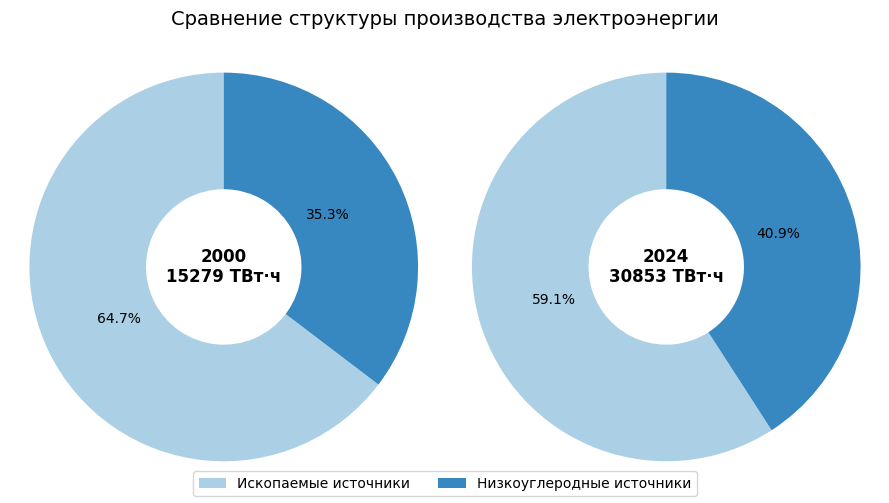

In [22]:
# вычислим доли выработки электроэнергии

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
years = [2000, 2024]
colors = sns.color_palette('Blues', n_colors=2)

for ax, year in zip(axes, years):
    data = df_year_short.loc[year, ['fossil_electricity', 'low_carbon_electricity']]
    total = data.sum()

    # Создаем кольцевую диаграмму
    wedges, texts, autotexts = ax.pie(
        data,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.6),
        textprops={'fontsize': 10}
    )

    # Центральный круг
    centre_circle = plt.Circle((0,0), 0.20, fc='white')
    ax.add_artist(centre_circle)

    # Текст в центре
    ax.text(0, 0, f'{year}\n{total:.0f} ТВт·ч',
            ha='center', va='center', fontsize=12, fontweight='bold')

    ax.axis('equal')

# Общая легенда
fig.legend(wedges, ['Ископаемые источники', 'Низкоуглеродные источники'],
           loc='lower center',
           ncol=2)

plt.suptitle('Сравнение структуры производства электроэнергии', fontsize=14)
plt.tight_layout()
plt.show()

Расчет показывает увеличение доли низкоуглеродной электроэнергии в общей структуре производства с 35,3% в 2000 году до 40,9% в 2024 году. Это уже выглядит более значительным. Оюнако надо понимать, что это общемировой показатель, и региональная статистика здесь сильно различается, что будет показано далее.

## 2.4. Доля мировой производимой электроэнергии в общей добыче ресурсов в 2024 году

Здесь мы как раз и посмотрим на долю выработки электроэнергии из общей добычи ресурсов.

In [23]:
cols_flat_cons = ['coal_consumption','gas_consumption','oil_consumption','nuclear_consumption','hydro_consumption', 'solar_consumption','wind_consumption','other_renewable_consumption']
cols_flat_el=['coal_electricity','gas_electricity','oil_electricity','nuclear_electricity','hydro_electricity', 'solar_electricity','wind_electricity','other_renewable_electricity']
cols_flat=list(zip(cols_flat_cons, cols_flat_el))
cols_to_bar=[item for sublist in cols_flat for item in sublist]


In [24]:
s_to_bar=df_year_short.loc[2024, cols_to_bar].transpose()
df_to_bar=pd.DataFrame(s_to_bar)
df_to_bar['mark']=['топливо','электроэнергия']*8

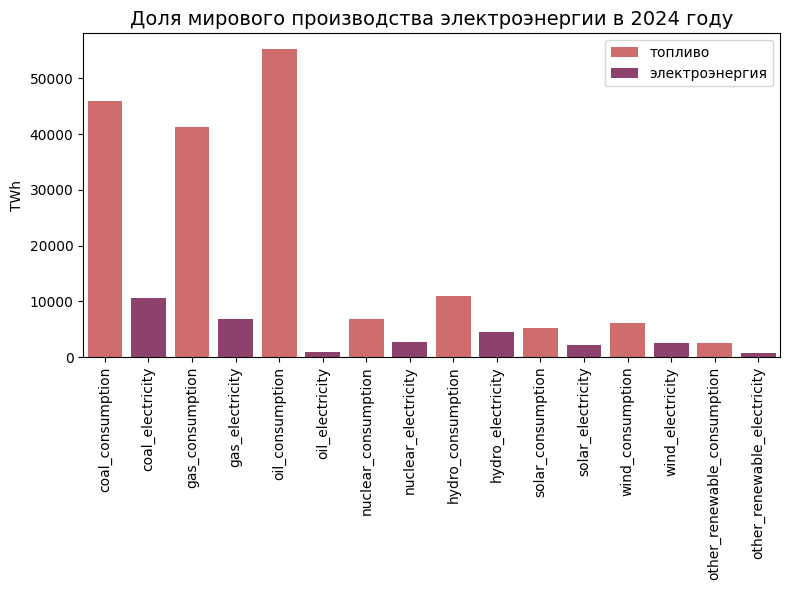

In [25]:
plt.figure(figsize=(8, 6))
sns.barplot(
    df_to_bar,
    x=df_to_bar.index,
    y=2024,
    hue='mark',
    palette='flare',

)
plt.title('Доля мирового производства электроэнергии в 2024 году', fontsize=14)
plt.xlabel('')
plt.ylabel('TWh')
plt.legend(loc='best')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [26]:
print(f"{(df_to_bar.loc['oil_electricity', 2024]*100/df_to_bar.loc['oil_consumption', 2024]):.2f}%")

1.55%


Как и предполагалось, уголь, газ и нефть используются промышленностью гораздо шире. Особенно интересно соотношение для нефти - всего 1.55% используется на электростанциях в виде мазута.

## 2.5. Региональная структура

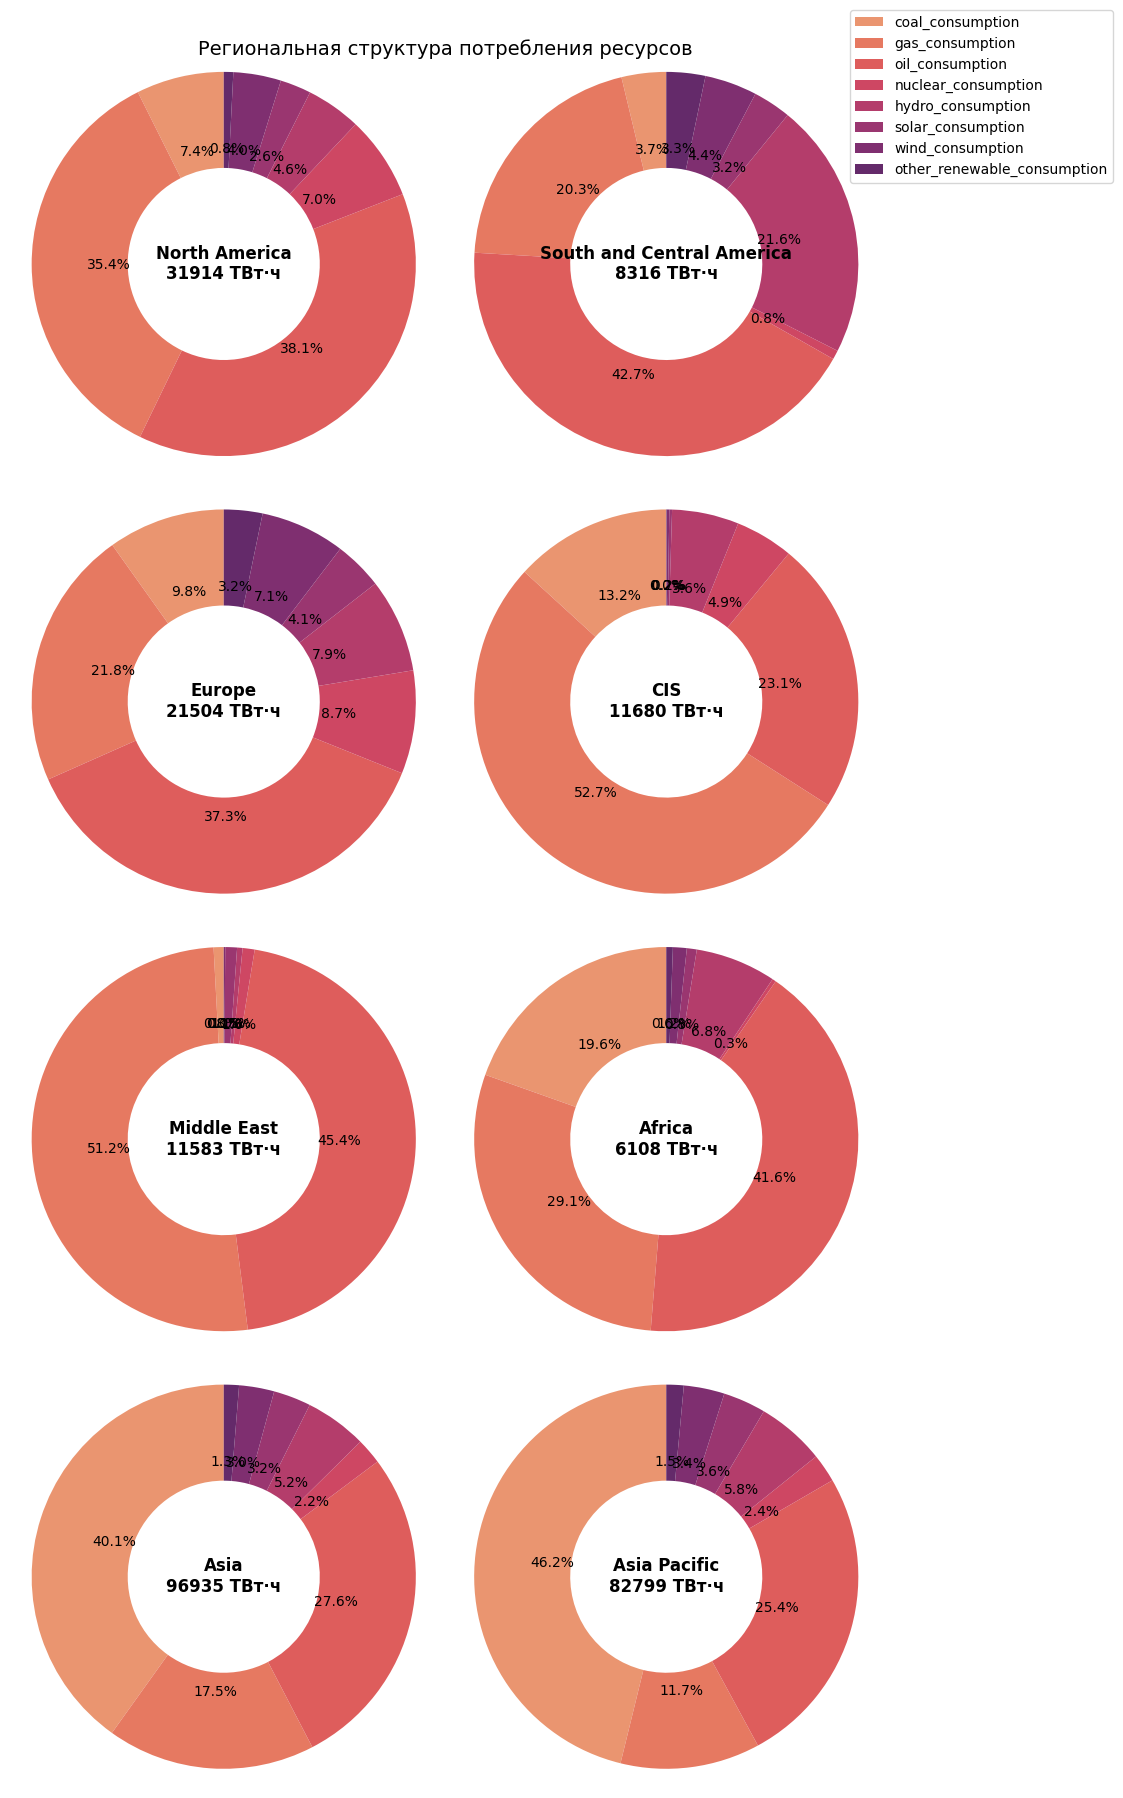

In [27]:
# выделим регионы согласно методологии EI и посмотрим статистику потребления топлива за 2024 год

regions = ['North America (EI)', 'South and Central America (EI)','Europe (EI)', 'CIS (EI)', 'Middle East (EI)', 'Africa (EI)', 'Asia', 'Asia Pacific (EI)']
cols_flat_cons = ['coal_consumption','gas_consumption','oil_consumption','nuclear_consumption','hydro_consumption', 'solar_consumption','wind_consumption','other_renewable_consumption']

fig, axes = plt.subplots(4, 2, figsize=(9, 18))
axes = axes.ravel()

colors = sns.color_palette('flare', n_colors=len(cols_flat_cons))

for ax, region in zip(axes, regions):
    data = df.loc[(df['country']==region) & (df['year']==2024), cols_flat_cons]
    total = data.values.sum()

    # Создаем кольцевую диаграмму
    wedges, texts, autotexts = ax.pie(
        data.values[0],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.5),
        textprops={'fontsize': 10}
    )

    # Центральный круг
    centre_circle = plt.Circle((0,0), 0.20, fc='white')
    ax.add_artist(centre_circle)

    # Текст в центре
    ax.text(0, 0, f'{region.rstrip(' (EI)')}\n{total:.0f} ТВт·ч',
            ha='center', va='center', fontsize=12, fontweight='bold')

    ax.axis('equal')

# Общая легенда
fig.legend(wedges, cols_flat_cons,
           loc='upper right',
           bbox_to_anchor=(1.25, 1))

plt.suptitle('Региональная структура потребления ресурсов', fontsize=14)
plt.tight_layout()
plt.show()

- Регион Южной и Центральной америки потребляет наибольшее количество низкоуглеродного топлива за счет значительной доли потребления гидроэнергии
- Далее следует Европа с максимальной (8,7%) долей атомной энергетики
- В странах СНГ более половины (52,7%) поребляемых ресурсов составляет газ
- В странах Ближнего Востока нефть и газ примерно пополам составляют все потребление и общий объем сравним со странами СНГ


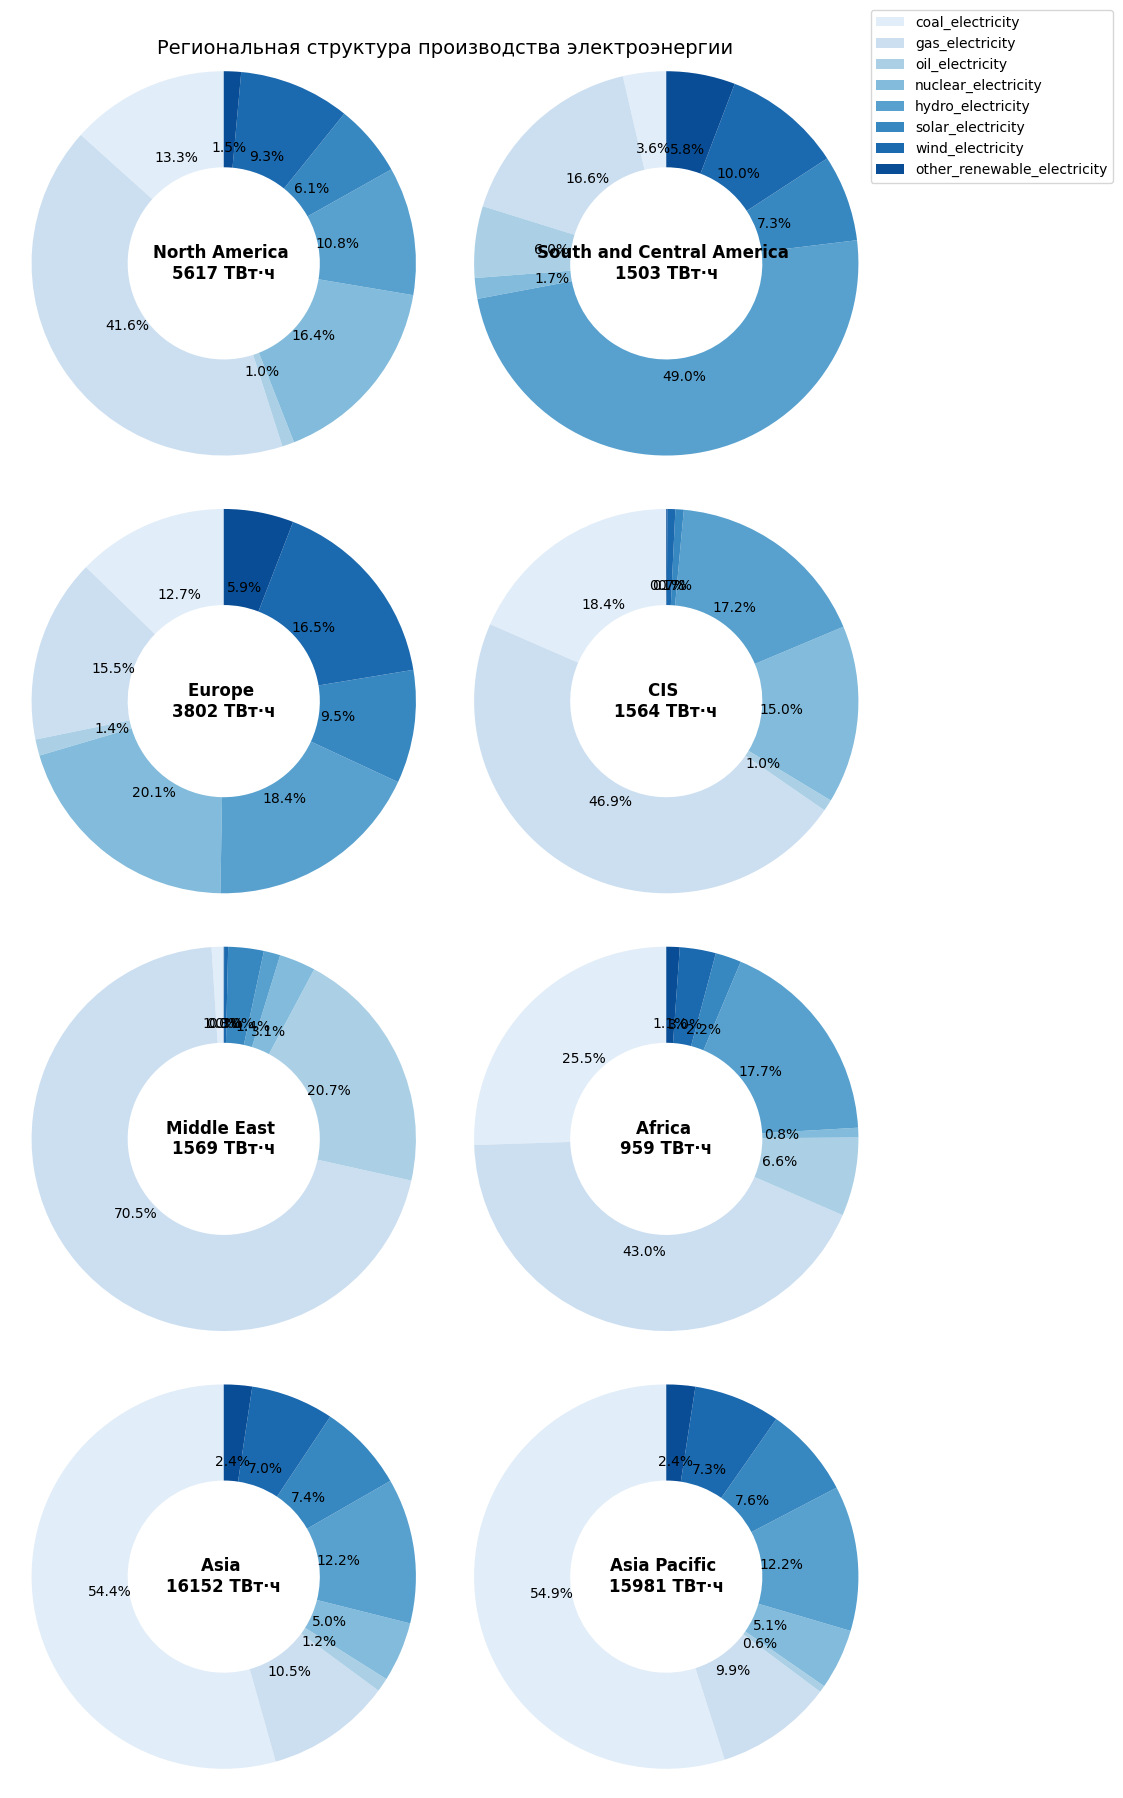

In [28]:
# посмотрим статистику производства электроэнергии за 2024 год

regions = ['North America (EI)', 'South and Central America (EI)','Europe (EI)', 'CIS (EI)', 'Middle East (EI)', 'Africa (EI)', 'Asia (Ember)', 'Asia Pacific (EI)']
cols_flat_el = ['coal_electricity','gas_electricity','oil_electricity','nuclear_electricity','hydro_electricity', 'solar_electricity','wind_electricity','other_renewable_electricity']

fig, axes = plt.subplots(4, 2, figsize=(9, 18))
axes = axes.ravel()

colors = sns.color_palette('Blues', n_colors=len(cols_flat_el))

for ax, region in zip(axes, regions):
    data = df.loc[(df['country']==region) & (df['year']==2024), cols_flat_el]
    total = data.values.sum()

    # Создаем кольцевую диаграмму
    wedges, texts, autotexts = ax.pie(
        data.values[0],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.5),
        textprops={'fontsize': 10}
    )

    # Центральный круг
    centre_circle = plt.Circle((0,0), 0.20, fc='white')
    ax.add_artist(centre_circle)

    # Текст в центре
    ax.text(0, 0, f'{region.rstrip('_(Ember)_(EI)')}\n{total:.0f} ТВт·ч',
            ha='center', va='center', fontsize=12, fontweight='bold')

    ax.axis('equal')

# Общая легенда
fig.legend(wedges, cols_flat_el,
           loc='upper right',
           bbox_to_anchor=(1.25, 1))

plt.suptitle('Региональная структура производства электроэнергии', fontsize=14)
plt.tight_layout()
plt.show()

- Регион Южной и Центральной америки примерно половину (49%) всей своей электронергии производит на гидростанциях
- В Европе максимальная мировая доля (20,1%) производства электроэнергии на атомных станциях
- В странах Ближнего Востока максимум в мире (70,5%) электроэнергии производится из газа
- В странах Азии максимальное количество (более 50%) электроэнергии производится из угля

## 2.6. Анализ выбросов СО2

### Мировые показатели

In [29]:
# сокращаем датасет, так как более ранние данные отсутствуют
df_world_short=df_world.set_index(['year'])
df_world_co2=df_world_short.loc[2000:]

In [30]:
cols_to_corr = ['population', 'carbon_intensity_elec',
                'coal_electricity','coal_share_elec',
                'fossil_electricity','fossil_share_elec',
                'gas_electricity','gas_share_elec',
                'greenhouse_gas_emissions',
                'hydro_electricity','hydro_share_elec',
                'low_carbon_electricity','low_carbon_share_elec',
                'nuclear_electricity','nuclear_share_elec',
                'oil_electricity','oil_share_elec',
                'other_renewable_electricity','other_renewables_share_elec',
                'renewables_electricity','renewables_share_elec',
                'solar_electricity','solar_share_elec',
                'wind_electricity','wind_share_elec']

In [31]:
cols_out = df_world_co2.columns.drop(cols_to_corr)

Подготовим датафрейм, содержащий электрические показатели для определения корреляций (объем СО2 изначально приведен к выработке электроэнергии)

In [32]:
df_world_co2.drop(cols_out, axis=1, inplace=True)
df_world_co2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 2000 to 2024
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   population                   25 non-null     float64
 1   carbon_intensity_elec        25 non-null     float64
 2   coal_electricity             25 non-null     float64
 3   coal_share_elec              25 non-null     float64
 4   fossil_electricity           25 non-null     float64
 5   fossil_share_elec            25 non-null     float64
 6   gas_electricity              25 non-null     float64
 7   gas_share_elec               25 non-null     float64
 8   greenhouse_gas_emissions     25 non-null     float64
 9   hydro_electricity            25 non-null     float64
 10  hydro_share_elec             25 non-null     float64
 11  low_carbon_electricity       25 non-null     float64
 12  low_carbon_share_elec        25 non-null     float64
 13  nuclear_electricity   

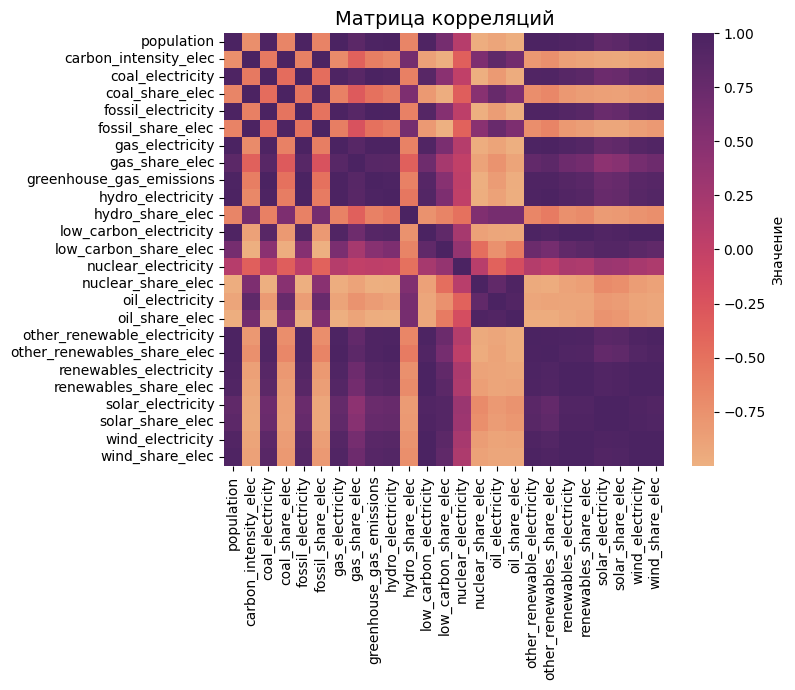

In [33]:
# построим матрицу кореляций
correlation_matrix = df_world_co2.corr()

plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, cmap='flare', cbar_kws={'label': 'Значение'})
plt.title('Матрица корреляций', fontsize=14)
plt.tight_layout()
plt.show()

Топ 5 корреляций с целевой величиной

In [34]:
correlation_matrix['greenhouse_gas_emissions'].sort_values(ascending=False).head()

,greenhouse_gas_emissions
greenhouse_gas_emissions,1.000000
fossil_electricity,0.999560
coal_electricity,0.998459
gas_electricity,0.984779
hydro_electricity,0.981522


Динамика роста производства электроэнергии из гидроресурсов и из угля практически сходны (см.выше), поэтому наблюдается высокая положительная корреляция с количеством выбросов СО2, хотя причинно-следственной связи здесь нет. В целом по той же причине ненаглядно показывать зависимости объемов выбросов от выработки электроэнергии из отдельных видов низкоуглеродных ресурсов, так как зависимость обеспечена сохранением темпов потребления ископаемых ресурсов.

Построим heatmap для интенсивности выбросов СО2 по годам/странам.

In [35]:
df_emissions_pivot=df.pivot_table(index='country',
                              columns='year',
                              values= 'carbon_intensity_elec'
                              )
df_emissions_pivot.head()

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
country,,,,,,,,,,,,,,,,,,,,,
ASEAN (Ember),572.859,570.606,573.028,577.339,583.917,585.559,584.788,588.491,578.753,579.845,...,595.113,591.490,572.067,577.894,597.715,589.474,571.416,554.268,570.005,569.948
Afghanistan,250.000,217.391,169.014,241.758,227.848,219.512,255.556,227.723,256.410,123.596,...,118.644,115.702,126.984,153.846,116.438,93.220,113.208,125.000,123.711,NaN
Africa,621.157,619.706,617.134,625.683,623.875,625.163,627.539,627.223,622.014,614.845,...,597.240,594.604,588.330,583.825,574.422,564.834,558.318,550.250,545.908,NaN
Africa (Ember),621.089,619.771,617.175,625.702,624.023,625.216,627.522,627.206,621.998,614.861,...,597.349,594.637,588.387,583.915,574.534,564.926,558.428,550.283,541.355,542.417
Albania,48.626,51.491,61.995,36.329,39.640,33.395,35.714,42.403,23.936,23.077,...,23.769,23.136,24.283,23.392,23.077,24.482,23.490,24.390,24.417,NaN


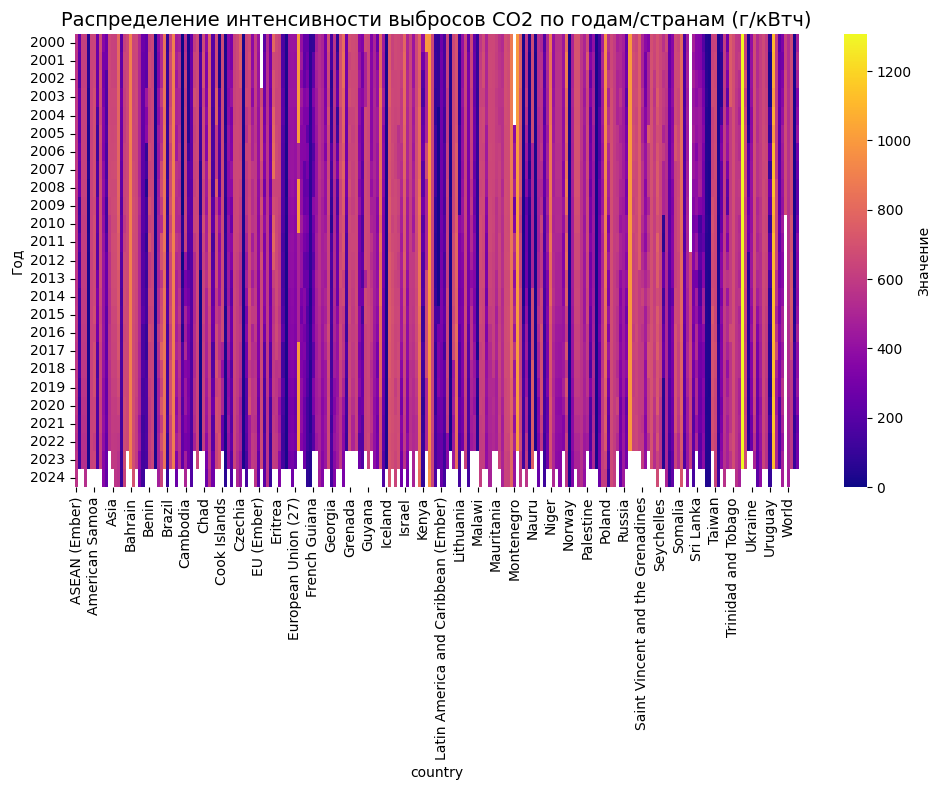

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_emissions_pivot.T, cmap='plasma', cbar_kws={'label': 'Значение'})
plt.ylabel('Год')
plt.title('Распределение интенсивности выбросов СО2 по годам/странам (г/кВтч)', fontsize=14)
plt.tight_layout()
plt.show()

Видим, что данные поступают только с 2000х годов и сильно разрежены в 2023 и 2024.

### Региональные данные по странам с наибольшим выбросом в 2024 году.

In [37]:
greenhouse_gas_2024 = df.loc[df['year']==2024, ['country','greenhouse_gas_emissions']].dropna().sort_values(by='greenhouse_gas_emissions', ascending=False)

In [38]:
greenhouse_gas_2024.head(10)

,country,greenhouse_gas_emissions
22807,World,14593.83
7862,G20 (Ember),12164.27
1371,Asia (Ember),9255.53
4571,China,5636.14
15170,OECD (Ember),3751.69
7887,G7 (Ember),2609.60
14596,North America (Ember),1792.45
21820,United States,1682.73
9618,India,1457.40
7190,Europe (Ember),1434.46


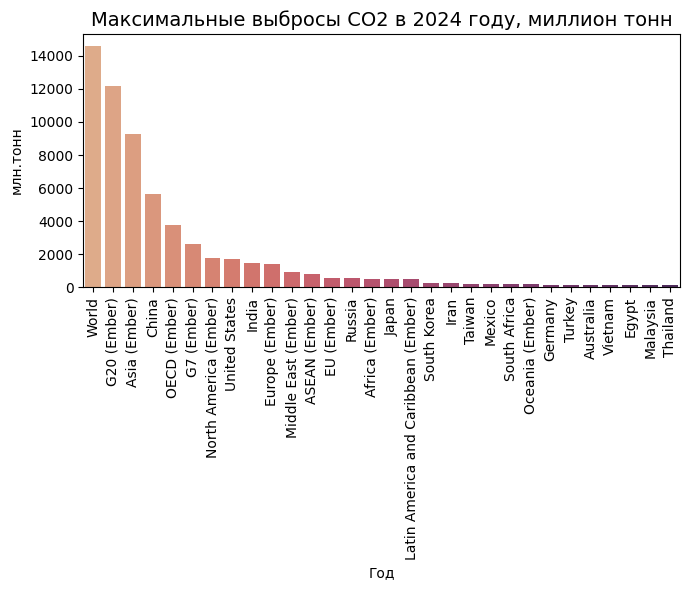

In [39]:
plt.figure(figsize=(7, 6))

sns.barplot(greenhouse_gas_2024.head(30),
            x='country',
            y='greenhouse_gas_emissions',
            palette='flare'
            )
plt.title('Максимальные выбросы СО2 в 2024 году, миллион тонн', fontsize=14)
plt.xlabel('Год')
plt.ylabel('млн.тонн')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [40]:
# выбираем колонки
cols_to_regions=['year', 'country', 'population',

                 'coal_electricity', 'gas_electricity', 'oil_electricity',
                 'nuclear_electricity', 'hydro_electricity',
                 'solar_electricity', 'wind_electricity',
                 'other_renewable_electricity',

                 'greenhouse_gas_emissions']

In [41]:
# выбираем нужные регионы
def mask(regions):
  country_mask=[df['country'][i] in regions for i in range(len(df['country']))]
  return country_mask

In [42]:
# сначала отдельные страны
countries_CO2 = ['China',
       'United States', 'India',
       'Russia', 'Japan',
       'South Korea', 'Iran',
       'Taiwan', 'Mexico', 'South Africa', 'Oceania (Ember)', 'Germany',
       'Turkey', 'Australia', 'Vietnam', 'Egypt', 'Malaysia', 'Thailand',
       'Canada', 'Poland', 'Kazakhstan', 'Bangladesh', 'Philippines',
       'Brazil', 'Italy', 'Pakistan', 'United Kingdom', 'Kuwait',
       'Argentina', 'Spain'
       ]

In [43]:
# затем группы стран
groups_CO2 = ['G20 (Ember)', 'Asia (Ember)', 'OECD (Ember)',
       'G7 (Ember)', 'North America (Ember)', 'Europe (Ember)', 'Middle East (Ember)',
       'ASEAN (Ember)','Africa (Ember)',
       'Latin America and Caribbean (Ember)']

В группу OECD входит 38 стран всех континентов. В отчетах Ember они часто выделяются отдельно, потому что :

- На них приходится значительная доля исторических выбросов

- Многие страны OECD активно сокращают использование угля (14 из 38 уже полностью отказались от угля!)

- Динамика энергоперехода в OECD отличается от развивающихся экономик (например, в 2024 году угольная генерация в OECD упала до 16% против 38% в пиковом 2003 году):

In [44]:
print(df.loc[df['country']=='OECD (Ember)', ['year','coal_share_elec']].sort_values('coal_share_elec').head(1))
print(df.loc[df['country']=='OECD (Ember)', ['year','coal_share_elec']].sort_values('coal_share_elec').tail(1))

       year  coal_share_elec
15170  2024           15.798
       year  coal_share_elec
15149  2003           37.644


In [45]:
# сформируем датасеты для сравнения

df_countries_CO2 = df.loc[mask(countries_CO2), cols_to_regions].copy().loc[df['year']>=2000,:]
df_groups_CO2 = df.loc[mask(groups_CO2), cols_to_regions].copy().loc[df['year']>=2000,:]

- Датасет по странам:

In [46]:
df_countries_CO2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750 entries, 1126 to 22442
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         750 non-null    int64  
 1   country                      750 non-null    object 
 2   population                   725 non-null    float64
 3   coal_electricity             750 non-null    float64
 4   gas_electricity              750 non-null    float64
 5   oil_electricity              750 non-null    float64
 6   nuclear_electricity          750 non-null    float64
 7   hydro_electricity            750 non-null    float64
 8   solar_electricity            750 non-null    float64
 9   wind_electricity             750 non-null    float64
 10  other_renewable_electricity  750 non-null    float64
 11  greenhouse_gas_emissions     750 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 76.2+ KB


In [47]:
df_emissions_countries_pivot=df_countries_CO2.pivot_table(index='year',
                              columns='country',
                              values= 'greenhouse_gas_emissions'
                              )
df_emissions_countries_pivot.head()

country,Argentina,Australia,Bangladesh,Brazil,Canada,China,Egypt,Germany,India,Iran,...,Russia,South Africa,South Korea,Spain,Taiwan,Thailand,Turkey,United Kingdom,United States,Vietnam
year,,,,,,,,,,,,,,,,,,,,,
2000,31.63,174.76,10.29,31.21,148.35,1061.86,38.54,326.08,422.85,79.66,...,412.59,168.41,134.07,104.04,117.63,58.12,71.41,196.82,2309.86,8.55
2001,27.23,180.11,11.25,34.74,150.26,1129.45,43.08,327.36,438.04,85.20,...,408.56,169.39,147.28,98.48,123.35,61.15,73.99,203.54,2273.43,8.90
2002,24.94,177.60,12.27,33.64,147.02,1278.82,46.82,332.49,460.74,90.10,...,412.79,176.96,156.97,115.62,130.10,64.32,68.91,201.71,2309.08,12.33
2003,29.13,178.99,13.01,33.04,148.03,1510.86,51.26,343.13,483.70,98.42,...,426.42,189.18,159.24,110.45,139.21,68.57,73.23,213.75,2345.91,15.38
2004,35.86,181.74,16.41,39.44,140.85,1714.96,55.01,338.12,505.44,104.42,...,422.92,197.38,170.25,124.24,144.99,74.39,74.01,211.15,2380.84,18.81


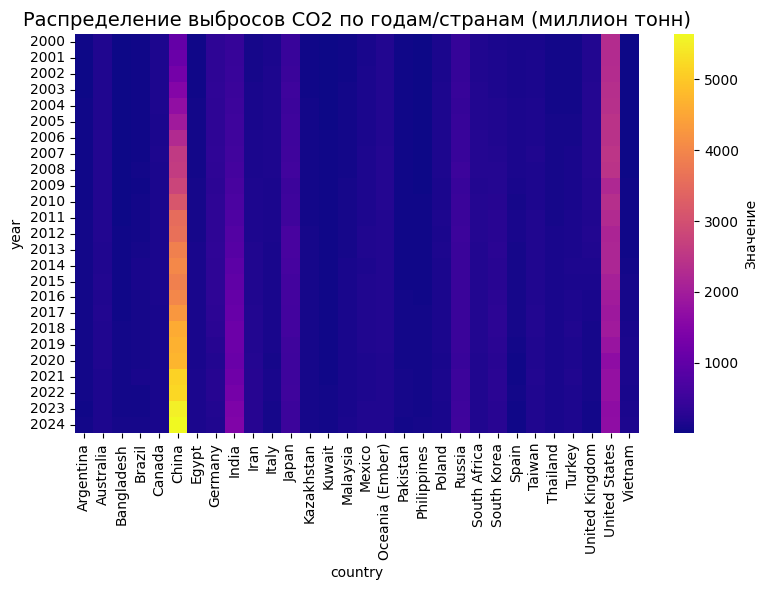

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_emissions_countries_pivot, cmap='plasma', cbar_kws={'label': 'Значение'})
plt.title('Распределение выбросов СО2 по годам/странам (миллион тонн)', fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
print(df_emissions_countries_pivot.loc[2000,'China'])
print(df_emissions_countries_pivot.loc[2024,'China'])

1061.86
5636.14


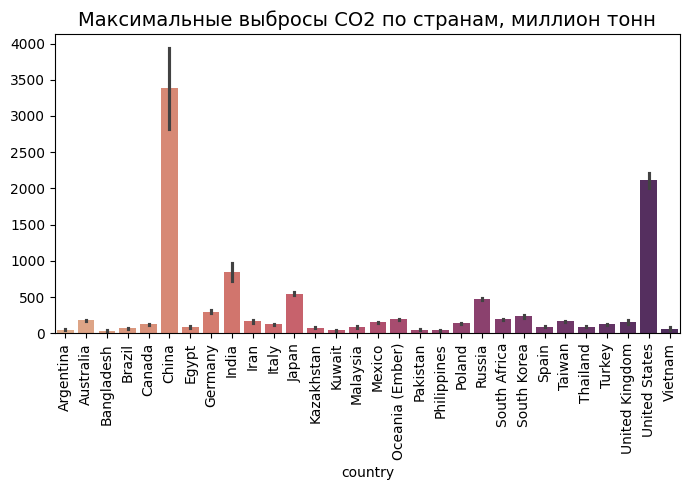

In [50]:
plt.figure(figsize=(7, 5))

sns.barplot(df_emissions_countries_pivot,
            palette='flare')
plt.title('Максимальные выбросы СО2 по странам, миллион тонн', fontsize=14)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Видим значительный отрыв Китая и США. Это связано с общими объемами потребления топлива даже при существенной доле низкоуглеродной электроэнергии.

- Датасет по группам:

In [51]:
df_groups_CO2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 15170
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         250 non-null    int64  
 1   country                      250 non-null    object 
 2   population                   0 non-null      float64
 3   coal_electricity             250 non-null    float64
 4   gas_electricity              250 non-null    float64
 5   oil_electricity              250 non-null    float64
 6   nuclear_electricity          250 non-null    float64
 7   hydro_electricity            250 non-null    float64
 8   solar_electricity            250 non-null    float64
 9   wind_electricity             250 non-null    float64
 10  other_renewable_electricity  250 non-null    float64
 11  greenhouse_gas_emissions     250 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 25.4+ KB


In [52]:
df_emissions_groups_pivot=df_groups_CO2.pivot_table(index='year',
                              columns='country',
                              values= 'greenhouse_gas_emissions'
                              )
df_emissions_groups_pivot.head()

country,ASEAN (Ember),Africa (Ember),Asia (Ember),Europe (Ember),G20 (Ember),G7 (Ember),Latin America and Caribbean (Ember),Middle East (Ember),North America (Ember),OECD (Ember)
year,,,,,,,,,,
2000,216.89,273.95,2624.36,1908.82,6994.31,3625.71,273.73,331.25,2458.29,4727.41
2001,231.01,284.76,2741.78,1922.18,7082.24,3586.67,287.01,350.87,2423.77,4723.24
2002,248.23,300.99,2969.78,1959.68,7370.45,3655.37,293.44,373.32,2456.20,4819.82
2003,264.56,318.57,3303.68,2040.40,7821.48,3766.22,310.26,394.90,2494.00,4971.51
2004,289.95,337.06,3573.50,2025.60,8094.68,3769.56,327.91,412.97,2521.77,4997.15


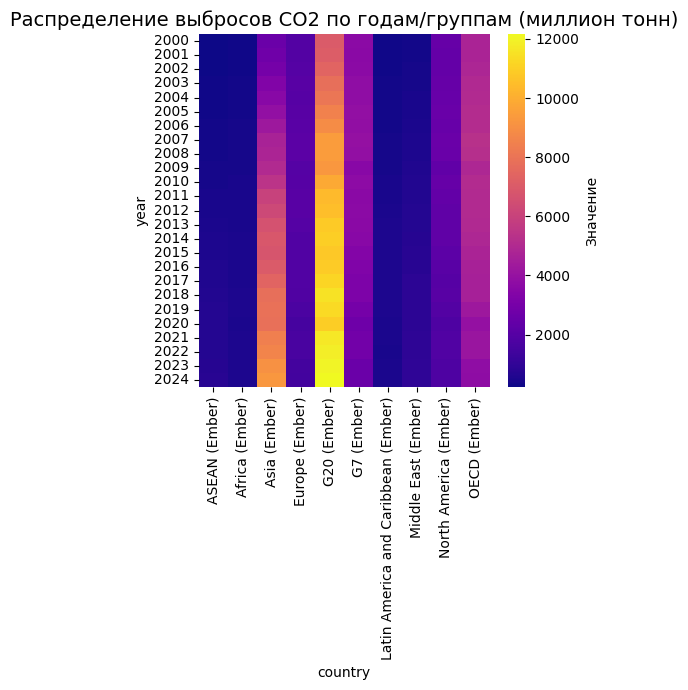

In [53]:
plt.figure(figsize=(5, 7))
sns.heatmap(df_emissions_groups_pivot, cmap='plasma', cbar_kws={'label': 'Значение'})
plt.title('Распределение выбросов СО2 по годам/группам (миллион тонн)', fontsize=14)
plt.tight_layout()
plt.show()

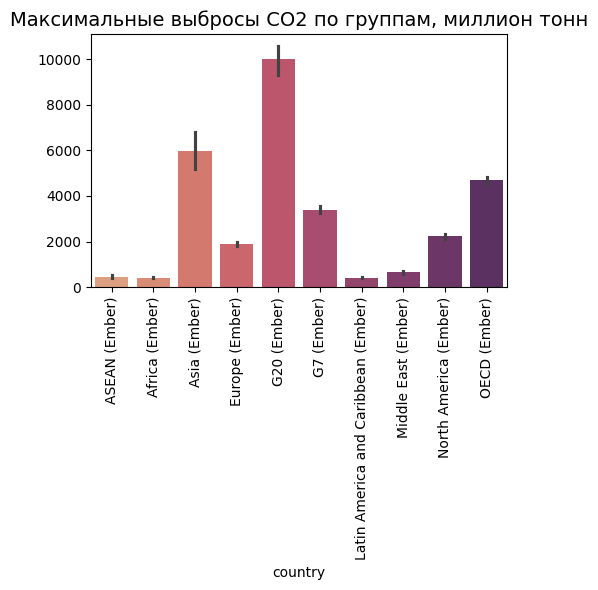

In [54]:
plt.figure(figsize=(5, 6))

sns.barplot(df_emissions_groups_pivot,
            palette='flare')
plt.title('Максимальные выбросы СО2 по группам, миллион тонн', fontsize=14)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Групповые статистики хоть и не так очевидны, но тоже весьма показательны. Так, например, Китай входит в G20, что дает максимальные показатели, но при этом не входит в OECD, откуда можно видеть, что в одной только Азии выбросов производится больше, чем всеми развитыми странами группы OECD (в т.ч. Канада, США, Мексика, страны Европы, Израиль, Австралия и прочие)

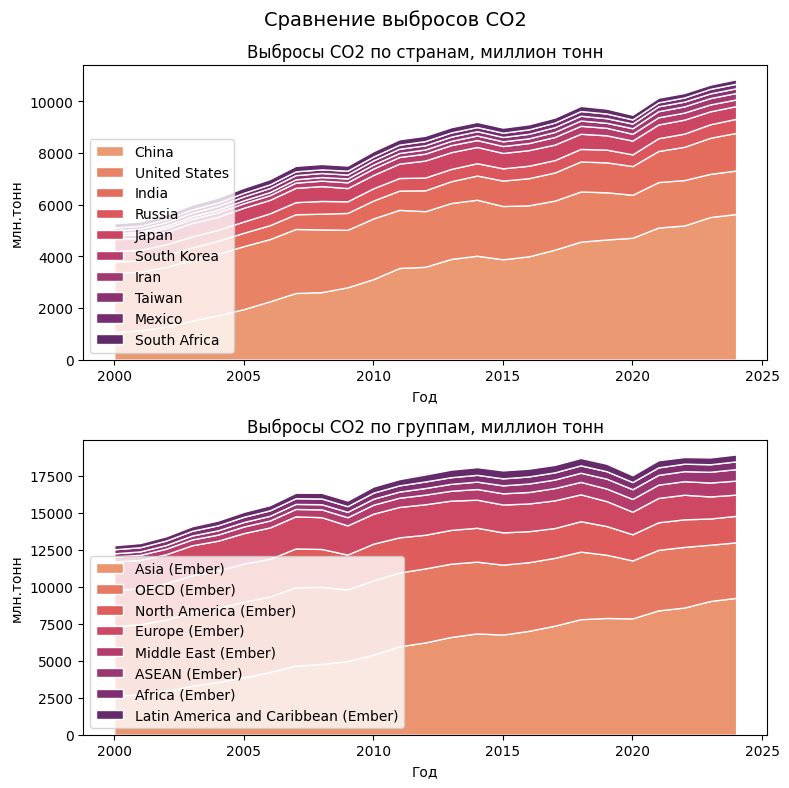

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
axes = axes.ravel()

cols_to_stack = [
    ['China', 'United States', 'India', 'Russia', 'Japan', 'South Korea', 'Iran', 'Taiwan', 'Mexico', 'South Africa'],
    ['Asia (Ember)', 'OECD (Ember)', 'North America (Ember)', 'Europe (Ember)', 'Middle East (Ember)', 'ASEAN (Ember)',
     'Africa (Ember)', 'Latin America and Caribbean (Ember)'],
    ]

df_to_stack = [df_emissions_countries_pivot, df_emissions_groups_pivot]

title = ['Выбросы СО2 по странам, миллион тонн','Выбросы СО2 по группам, миллион тонн']

for idx,ax in enumerate(axes):
    ax.stackplot(df_to_stack[idx].index,
                 [df_to_stack[idx][col] for col in cols_to_stack[idx]],
                 labels=cols_to_stack[idx],
                 edgecolor='white',
                 colors=sns.color_palette("flare", len(cols_to_stack[idx]))
                 )
    ax.set_title(f'{title[idx]}', fontsize=12)
    ax.set_xlabel('Год')
    ax.set_ylabel('млн.тонн')
    ax.legend(loc='lower left', fontsize=10)
    #ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle('Сравнение выбросов СО2', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Моделирование

In [157]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, KFold

In [158]:
# для моделирования возьмем сформированный датасет

df_countries_CO2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750 entries, 1126 to 22442
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         750 non-null    int64  
 1   country                      750 non-null    object 
 2   population                   750 non-null    float64
 3   coal_electricity             750 non-null    float64
 4   gas_electricity              750 non-null    float64
 5   oil_electricity              750 non-null    float64
 6   nuclear_electricity          750 non-null    float64
 7   hydro_electricity            750 non-null    float64
 8   solar_electricity            750 non-null    float64
 9   wind_electricity             750 non-null    float64
 10  other_renewable_electricity  750 non-null    float64
 11  greenhouse_gas_emissions     750 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 76.2+ KB


In [159]:
df_countries_CO2.fillna(0, inplace=True)

In [160]:
target_col='greenhouse_gas_emissions'
cols_to_encode = 'country'

In [161]:
feature_cols = [col for col in df_countries_CO2 if col not in ['year', target_col]]

In [162]:
x_train, x_test, y_train, y_test = train_test_split(df_countries_CO2[feature_cols], df_countries_CO2[target_col], test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)

(600, 10) (150, 10)


In [163]:
num_cols=feature_cols.copy()
num_cols.remove(cols_to_encode)

In [164]:
#создаем препроцессор
preprocessor = ColumnTransformer([
    ('numeric', MinMaxScaler(), num_cols),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), [cols_to_encode])
    ])

In [165]:
#создаем набор моделей
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
}

In [166]:
results = []

for name, model in models.items():
    # Создаем пайплайн
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Обучаем
    pipeline.fit(x_train, y_train)

    # Предсказываем
    y_pred = pipeline.predict(x_test)

    # Метрики
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

In [167]:
# Сравнение моделей
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("Результаты (по убыванию R2):")
print(results_df.to_string(index=False))

Результаты (по убыванию R2):
            Model       MAE      RMSE       R2
Linear Regression  3.328247  5.146782 0.999935
            Lasso 11.233582 16.136060 0.999359
          XGBoost 11.404412 28.829149 0.997954
Gradient Boosting 13.438269 38.570560 0.996337
    Random Forest 15.088851 44.313823 0.995166
            Ridge 32.968045 57.567200 0.991841
         LightGBM 31.267392 99.525369 0.975614


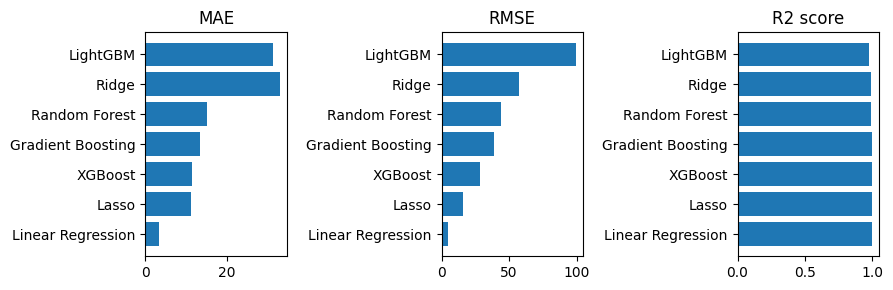

In [168]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# MAE
axes[0].barh(results_df['Model'], results_df['MAE'])
axes[0].set_title('MAE')

# RMSE
axes[1].barh(results_df['Model'], results_df['RMSE'])
axes[1].set_title('RMSE')

# R2
axes[2].barh(results_df['Model'], results_df['R2'])
axes[2].set_title('R2 score')

plt.tight_layout()
plt.show()

Анализ лучшей модели

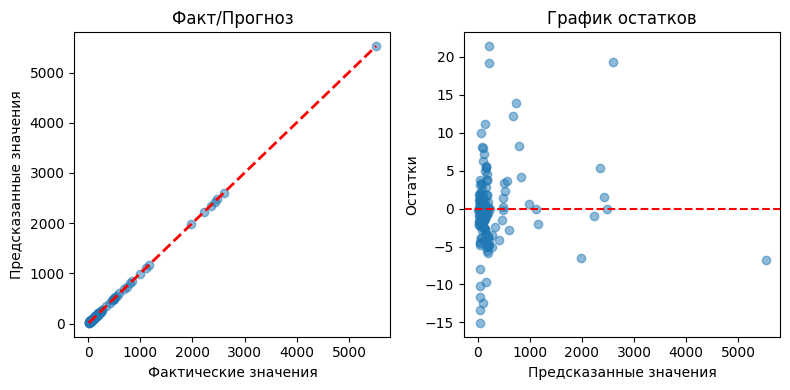

In [169]:
best_model = models['Linear Regression']

# Обучаем для анализа
pipeline_best = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', best_model)
])
pipeline_best.fit(x_train, y_train)
y_pred_best = pipeline_best.predict(x_test)

# 1. Факт vs Прогноз
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_pred_best.min(), y_pred_best.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Факт/Прогноз')

# 2. Остатки
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')

plt.tight_layout()
plt.show()

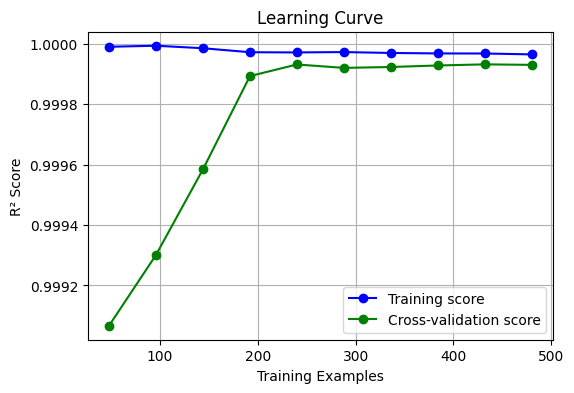

In [170]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    pipeline_best, x_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Cross-validation score')
plt.title('Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Тюнинг модели с худшим результатом

In [171]:
from sklearn.model_selection import GridSearchCV

# Для LightGBM
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.8, 1.0]
}

cv = KFold(n_splits=4, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(random_state=42))
    ]),
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)



print(f"\nЛучшие параметры: {grid_search.best_params_}")

# Оценка на тесте
y_pred_tuned = grid_search.predict(x_test)
print(f"\nПосле тюнинга:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_tuned):.2f}")
print(f"R2: {r2_score(y_test, y_pred_tuned):.4f}")


Лучшие параметры: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}

После тюнинга:
MAE: 12.68
RMSE: 38.67
R2: 0.9963


Первоначальные параметры:
(n_estimators=100, learning_rate=0.1, max_depth=5)

До тюнинга:

MAE: 31.267392

RMSE: 99.525369

R2: 0.975614

Лучшие параметры:
(n_estimators=200, learning_rate=0.1, max_depth=5)

После тюнинга:

MAE: 12.68

RMSE: 38.67

R2: 0.9963

Вывод: в целом данные не имеют случайных выбросов, хорошо структурированы и непосредственно влияют на целевую переменную, поэтому линейная модель хорошо обучается и показывает высокие результаты на тесте даже без дополнительного подбора гиперпараметров. Модель градиентного бустинга, показавшая наихудшие начальные результаты, поддается настройке с подбором параметров по сетке и позволяет улучшить свои оценки на итоговом тесте.